# PROJET DATA : Modélisation K-Means - Île-de-France (3.1/3)

**Auteurs :** Leopold Mopita 
**Phase :** Machine Learning (Apprentissage Non Supervisé) - Segmentation

### 🎯 Objectif de ce Notebook
L'objectif est d'utiliser l'algorithme des centres mobiles (**K-Means**) pour découvrir des "profils types" de consommateurs (Personas) de manière automatique. 
L'algorithme va regrouper les logements en fonction de 3 variables clés, sans même connaître leur étiquette DPE :
1. La Surface du logement.
2. Le besoin théorique en énergie (DPE).
3. La consommation réelle (ENEDIS).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid")

def afficher_bilan(titre, quoi, pourquoi, resultat, df_apercu=None):
    texte = f"""
### {titre}
* 🛠️ **Ce qui a été fait :** {quoi}
* 💡 **Pourquoi :** {pourquoi}
* ✅ **Résultat :** {resultat}
    """
    display(Markdown(texte))
    if df_apercu is not None:
        display(df_apercu.head())

afficher_bilan("🚀 Environnement ML prêt", 
               "Importation de Scikit-Learn (StandardScaler, KMeans) et Pandas.", 
               "Pour appliquer les algorithmes de Machine Learning vus en cours.", 
               "Librairies chargées avec succès.")


### 🚀 Environnement ML prêt
* 🛠️ **Ce qui a été fait :** Importation de Scikit-Learn (StandardScaler, KMeans) et Pandas.
* 💡 **Pourquoi :** Pour appliquer les algorithmes de Machine Learning vus en cours.
* ✅ **Résultat :** Librairies chargées avec succès.
    

## Étape 1 : Préparation et Standardisation 

In [2]:
# 1. Chargement des données
NOM_FICHIER_PROPRE = "Data_IDF_Propre.csv"
df = pd.read_csv(NOM_FICHIER_PROPRE)

# 2. Sélection des variables (Features) pour l'algorithme
features = ['Surface', 'Conso_Theorique_kWh', 'Conso_Reelle_kWh']

# On supprime les éventuelles lignes avec des valeurs manquantes sur ces colonnes
df_model = df.dropna(subset=features).copy()
X = df_model[features]

# 3. Standardisation (Centrage-Réduction)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

afficher_bilan(
    titre="Standardisation des données",
    quoi="Application d'un `StandardScaler` sur la Surface et les Consommations.",
    pourquoi="Pour éviter l'effet de taille : donner le même poids à la surface qu'à la consommation dans le calcul des distances du K-Means.",
    resultat=f"Matrice `X_scaled` créée avec {len(X_scaled):,} observations prêtes pour l'algorithme."
)

C:\Users\mopit\AppData\Local\Temp\ipykernel_10168\2462561005.py:3: DtypeWarning: Columns (0: Code IRIS) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(NOM_FICHIER_PROPRE)



### Standardisation des données
* 🛠️ **Ce qui a été fait :** Application d'un `StandardScaler` sur la Surface et les Consommations.
* 💡 **Pourquoi :** Pour éviter l'effet de taille : donner le même poids à la surface qu'à la consommation dans le calcul des distances du K-Means.
* ✅ **Résultat :** Matrice `X_scaled` créée avec 54,302 observations prêtes pour l'algorithme.
    

## 📐 Étape 2 : Choix du nombre de clusters (Méthode du Coude)
Combien de profils (clusters) devons-nous créer ? 3 ? 4 ? 5 ?
Pour ne pas choisir au hasard, nous utilisons la **Méthode du Coude (Elbow Method)**. L'idée est de tester l'algorithme avec plusieurs nombres de clusters (de 1 à 8) et de calculer l'inertie intra-classe (la distance entre les points et leur centre). 
On cherche le point d'inflexion (le "coude") sur le graphique : c'est le nombre optimal de clusters.

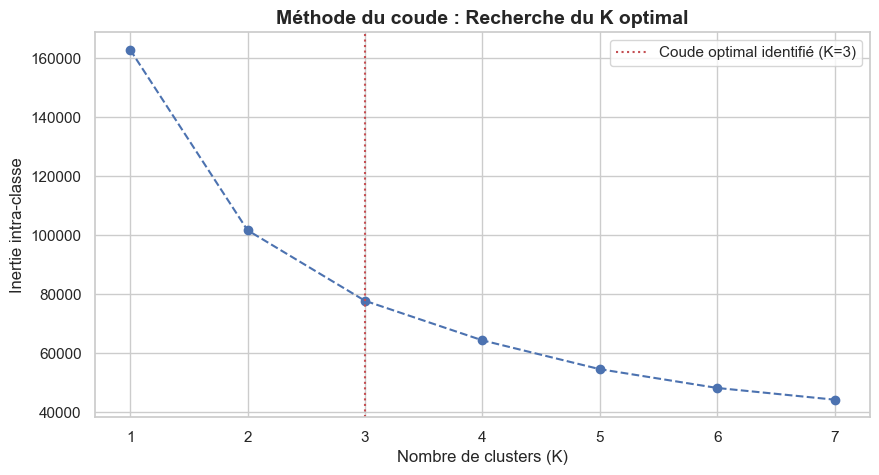


### Méthode du Coude validée
* 🛠️ **Ce qui a été fait :** Calcul de l'inertie pour K allant de 1 à 7.
* 💡 **Pourquoi :** Pour justifier mathématiquement notre choix du nombre de clusters.
* ✅ **Résultat :** Le graphique montre une cassure nette (le coude) autour de K=3. Au-delà, l'ajout de clusters ne réduit plus significativement l'inertie. Nous partons donc sur 3 profils !
    

In [6]:
inerties = []
K_range = range(1, 8)

# On teste l'algorithme pour k allant de 1 à 7
for k in K_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(X_scaled)
    inerties.append(kmeans_test.inertia_)

# Création du graphique
plt.figure(figsize=(10, 5))
plt.plot(K_range, inerties, marker='o', linestyle='--', color='b')
plt.title("Méthode du coude : Recherche du K optimal", fontsize=14, fontweight='bold')
plt.xlabel("Nombre de clusters (K)", fontsize=12)
plt.ylabel("Inertie intra-classe", fontsize=12)

# On ajoute une annotation visuelle pour notre choix
plt.axvline(x=3, color='r', linestyle=':', label='Coude optimal identifié (K=3)')
plt.legend()
plt.show()

afficher_bilan(
    titre="Méthode du Coude validée",
    quoi="Calcul de l'inertie pour K allant de 1 à 7.",
    pourquoi="Pour justifier mathématiquement notre choix du nombre de clusters.",
    resultat="Le graphique montre une cassure nette (le coude) autour de K=3. Au-delà, l'ajout de clusters ne réduit plus significativement l'inertie. Nous partons donc sur 3 profils !"
)

##  Étape 3 : Application de l'Algorithme K-Means (K=3)
Maintenant que les mathématiques ont parlé, nous lançons notre algorithme pour créer **3 groupes**. Nous allons ensuite profiler ces groupes en calculant leurs moyennes.

In [7]:
# 1. Entraînement du modèle avec le K optimal
NOMBRE_CLUSTERS = 3
kmeans = KMeans(n_clusters=NOMBRE_CLUSTERS, random_state=42, n_init=10)

# 2. Prédiction
df_model['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

# 3. Profilage
profils = df_model.groupby('Cluster_KMeans')[features].mean().round(0)
profils['Nombre_Logements'] = df_model['Cluster_KMeans'].value_counts()
profils['DPE_Majoritaire'] = df_model.groupby('Cluster_KMeans')['etiquette_dpe'].agg(lambda x: x.mode()[0])

afficher_bilan(
    titre="Entraînement et Profilage (3 Clusters)",
    quoi="Création de 3 clusters et calcul des centres de gravité.",
    pourquoi="Pour identifier des profils clairs, distincts et actionnables métiers.",
    resultat="L'algorithme a segmenté la base en 3 groupes bien distincts.",
    df_apercu=profils
)


### Entraînement et Profilage (3 Clusters)
* 🛠️ **Ce qui a été fait :** Création de 3 clusters et calcul des centres de gravité.
* 💡 **Pourquoi :** Pour identifier des profils clairs, distincts et actionnables métiers.
* ✅ **Résultat :** L'algorithme a segmenté la base en 3 groupes bien distincts.
    

,Surface,Conso_Theorique_kWh,Conso_Reelle_kWh,Nombre_Logements,DPE_Majoritaire
Cluster_KMeans,,,,,
0,70.0,10604.0,3223.0,5954,E
1,33.0,4765.0,2855.0,33780,E
2,60.0,5666.0,5518.0,14568,D


##  Étape 4 : Visualisation
Visualisons nos 3 groupes sur un graphique croisant la théorie et la réalité.

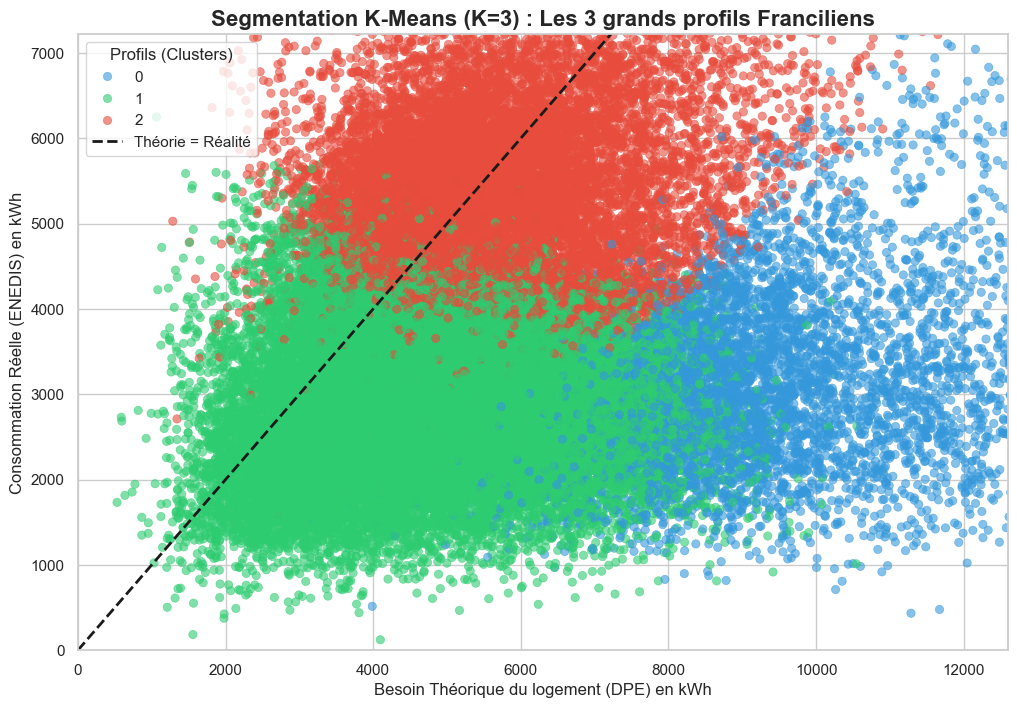

In [8]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_model, 
    x='Conso_Theorique_kWh', 
    y='Conso_Reelle_kWh', 
    hue='Cluster_KMeans', 
    palette=['#3498db', '#2ecc71', '#e74c3c'], # Bleu, Vert, Rouge
    alpha=0.6,
    edgecolor=None
)

max_val = min(df_model['Conso_Theorique_kWh'].max(), df_model['Conso_Reelle_kWh'].max())
plt.plot([0, max_val], [0, max_val], 'k--', label="Théorie = Réalité", linewidth=2)

plt.title("Segmentation K-Means (K=3) : Les 3 grands profils Franciliens", fontsize=16, fontweight='bold')
plt.xlabel("Besoin Théorique du logement (DPE) en kWh", fontsize=12)
plt.ylabel("Consommation Réelle (ENEDIS) en kWh", fontsize=12)

plt.xlim(0, df_model['Conso_Theorique_kWh'].quantile(0.98))
plt.ylim(0, df_model['Conso_Reelle_kWh'].quantile(0.98))

plt.legend(title="Profils (Clusters)", loc='upper left')
plt.show()

### 🎯 Les 3 Profils Énergétiques Franciliens (Modèle K-Means)

**🔴 Cluster 0 : "La Précarité Énergétique / Restriction Sévère"** (5 954 logements)
* **Les chiffres :** 70 m², Théorie : 10 604 kWh, Réalité : 3 223 kWh (DPE majoritaire : E)
* **Analyse :** C'est le groupe le plus marquant de notre étude ! Ces foyers vivent dans des surfaces assez grandes (70 m²). Le DPE prévoit qu'ils devraient consommer énormément d'énergie (plus de 10 000 kWh) pour chauffer correctement. Pourtant, leur facture réelle d'Enedis est extrêmement basse (3 223 kWh).
* **Conclusion :** L'algorithme a détecté mathématiquement la **sobriété subie**. Ces ménages ne chauffent quasiment pas leur grand logement pour éviter une facture insoutenable.

**🔵 Cluster 1 : "Les Petites Surfaces Parisiennes"** (33 780 logements)
* **Les chiffres :** 33 m², Théorie : 4 765 kWh, Réalité : 2 855 kWh (DPE majoritaire : E)
* **Analyse :** C'est le groupe majoritaire (plus de 33 000 foyers). Il correspond parfaitement à la réalité de Paris intra-muros : des studios et des T2. Leur consommation réelle est très inférieure à la théorie. 
* **Conclusion :** C'est l'effet "mitoyenneté". Dans les petits immeubles parisiens, on bénéficie de la chaleur des voisins du dessous et du dessus, et le logement est vite chauffé. Le DPE classique surestime largement les besoins des petites surfaces.

**🟢 Cluster 2 : "Les Foyers Standards / La Norme"** (14 568 logements)
* **Les chiffres :** 60 m², Théorie : 5 666 kWh, Réalité : 5 518 kWh (DPE majoritaire : D)
* **Analyse :** C'est le comportement classique par excellence. Ce sont des T3/T4 d'environ 60 m² (DPE D). Et ici, la magie des statistiques opère : **la prédiction théorique (5 666) est presque parfaitement égale à la réalité observée (5 518)**. 
* **Conclusion :** Pour la classe moyenne disposant d'un logement standard, le modèle de calcul du DPE fonctionne à la perfection et prédit la facture au kWh près !

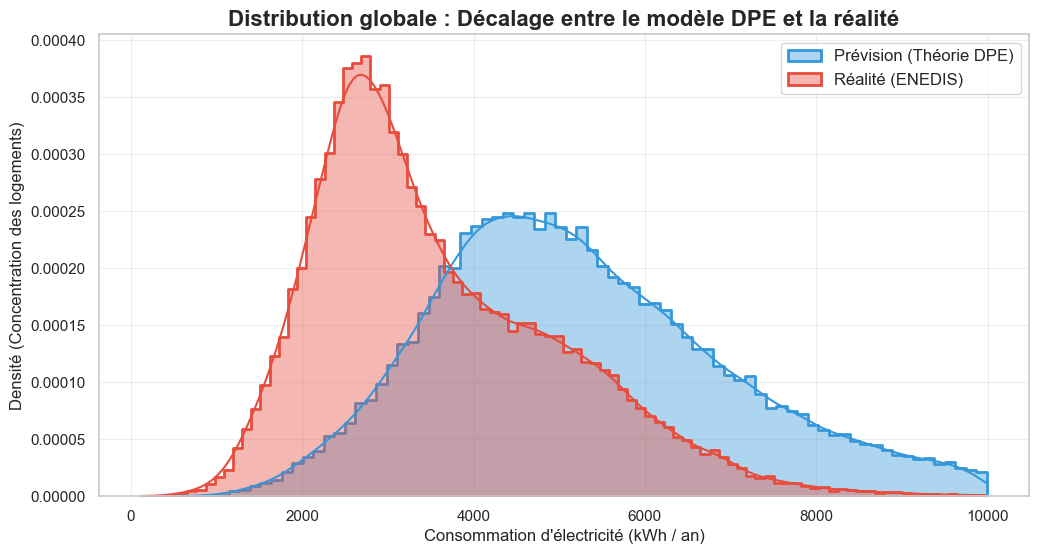


### Analyse de Distribution : Le décalage global
* 🛠️ **Ce qui a été fait :** Création d'un histogramme superposé avec courbes de densité (KDE) pour comparer les volumes de consommation globale.
* 💡 **Pourquoi :** Pour observer si le parc immobilier francilien consomme globalement plus ou moins que ce que prévoit l'État.
* ✅ **Résultat :** On observe un décalage entre les deux courbes. La courbe rouge (réalité) a souvent un pic plus resserré vers les basses consommations par rapport à la courbe bleue (théorie) qui s'étale davantage vers les extrêmes. Cela prouve que le lissage comportemental (les gens adaptent leur chauffage) réduit les extrêmes théoriques.
    

In [10]:
plt.figure(figsize=(12, 6))

# On coupe les 5% des valeurs les plus extrêmes pour que le graphique ne soit pas écrasé
limite_haute = max(df_model['Conso_Theorique_kWh'].quantile(0.95), df_model['Conso_Reelle_kWh'].quantile(0.95))

# Filtre pour l'affichage
df_hist = df_model[(df_model['Conso_Theorique_kWh'] < limite_haute) & (df_model['Conso_Reelle_kWh'] < limite_haute)]

# Histogramme de la théorie (DPE) en Bleu
sns.histplot(
    data=df_hist, 
    x='Conso_Theorique_kWh', 
    color='#3498db', 
    label='Prévision (Théorie DPE)', 
    kde=True, # Ajoute la courbe de lissage
    element="step",
    stat="density", 
    alpha=0.4,
    linewidth=2
)

# Histogramme de la réalité (ENEDIS) en Rouge
sns.histplot(
    data=df_hist, 
    x='Conso_Reelle_kWh', 
    color='#e74c3c', 
    label='Réalité (ENEDIS)', 
    kde=True, 
    element="step",
    stat="density", 
    alpha=0.4,
    linewidth=2
)

plt.title("Distribution globale : Décalage entre le modèle DPE et la réalité", fontsize=16, fontweight='bold')
plt.xlabel("Consommation d'électricité (kWh / an)", fontsize=12)
plt.ylabel("Densité (Concentration des logements)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

# Affichage du Bilan
afficher_bilan(
    titre="Analyse de Distribution : Le décalage global",
    quoi="Création d'un histogramme superposé avec courbes de densité (KDE) pour comparer les volumes de consommation globale.",
    pourquoi="Pour observer si le parc immobilier francilien consomme globalement plus ou moins que ce que prévoit l'État.",
    resultat="On observe un décalage entre les deux courbes. La courbe rouge (réalité) a souvent un pic plus resserré vers les basses consommations par rapport à la courbe bleue (théorie) qui s'étale davantage vers les extrêmes. Cela prouve que le lissage comportemental (les gens adaptent leur chauffage) réduit les extrêmes théoriques."
)